##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
!pip -q install keras-cv tensorflow tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 52.8 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import keras_cv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [6]:
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)

# Resize layer REQUIRED by the lab
inference_resizing = keras_cv.layers.Resizing(
    640, 640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh"
)

print("Model loaded ✅")

100%|██████████| 2.27k/2.27k [00:00<00:00, 3.90MB/s]


100%|██████████| 99.5M/99.5M [00:02<00:00, 39.0MB/s]


Model loaded ✅


In [7]:
ds = tfds.load("voc/2012", split="validation", shuffle_files=True)

# Pascal VOC label names (20 classes)
VOC_CLASSES = [
    "aeroplane","bicycle","bird","boat","bottle","bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person","pottedplant","sheep","sofa","train","tvmonitor"
]

def extract_main_class(example):
    # Take the first object label in the image (simple & good for this lab)
    labels = example["objects"]["label"]
    return labels[0]

# Collect 5 examples with different (first-object) classes
picked = []
seen = set()

for ex in tfds.as_numpy(ds.take(500)):  # search up to 500 to find variety
    first_label = int(ex["objects"]["label"][0])
    if first_label not in seen:
        seen.add(first_label)
        picked.append(ex)
    if len(picked) == 5:
        break

print("Picked classes:", [VOC_CLASSES[int(x["objects"]["label"][0])] for x in picked])

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.T3DRQA_5.0.0/voc-train.tfrecord*...:   0%|          | …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.T3DRQA_5.0.0/voc-validation.tfrecord*...:   0%|       …

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2012/5.0.0. Subsequent calls will reuse this data.
Picked classes: ['cat', 'motorbike', 'train', 'person', 'boat']


In [9]:
# Build a batch of images (uint8 is fine)
# Apply resizing to each image BEFORE stacking
processed_images = []
for x in picked:
    # Convert numpy array to TensorFlow tensor and cast to float32
    img_tensor = tf.convert_to_tensor(x["image"], dtype=tf.float32)
    # Resize the image using the defined layer
    resized_img_tensor = inference_resizing(img_tensor)
    # Convert the resized tensor back to numpy and add to list
    processed_images.append(resized_img_tensor.numpy())

images = np.stack(processed_images, axis=0)

# Predict using the already resized and stacked images
predictions = model.predict(images, verbose=0)

# predictions format:
# predictions["boxes"] -> (B, N, 4) in xywh
# predictions["classes"] -> (B, N)
# predictions["confidence"] -> (B, N)
predictions.keys()

dict_keys(['boxes', 'confidence', 'classes', 'num_detections'])

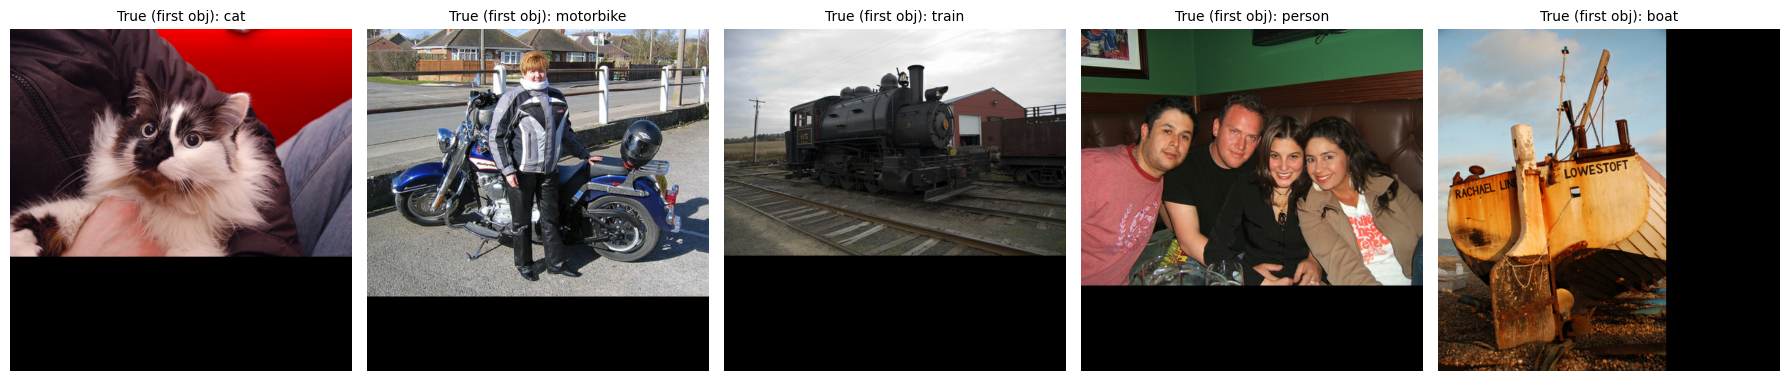

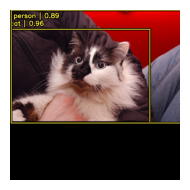

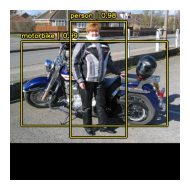

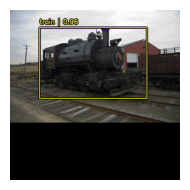

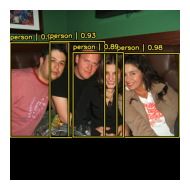

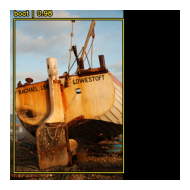

In [12]:
def draw_yolo_predictions(image, boxes, classes, conf, conf_thresh=0.30):
    # Filter by confidence
    keep = conf >= conf_thresh
    boxes = boxes[keep]
    classes = classes[keep].astype(int)
    conf = conf[keep]

    # KerasCV visualizer expects dict
    vis = keras_cv.visualization.plot_bounding_box_gallery(
        images=np.expand_dims(image, axis=0),
        value_range=(0, 255),
        rows=1,
        cols=1,
        y_true=None,
        y_pred={
            "boxes": np.expand_dims(boxes, axis=0),
            "classes": np.expand_dims(classes, axis=0),
            "confidence": np.expand_dims(conf, axis=0),
        },
        bounding_box_format="xywh",
        class_mapping={i: VOC_CLASSES[i] for i in range(len(VOC_CLASSES))},
        show=True,
        font_scale=0.8
    )
    return boxes, classes, conf

# Show 5 images side-by-side with detections
plt.figure(figsize=(18, 8))

for i in range(5):
    img = images[i] # Changed from resized[i]
    boxes = predictions["boxes"][i]
    classes = predictions["classes"][i]
    conf = predictions["confidence"][i]

    # Plot the image itself as a grid label
    plt.subplot(1, 5, i+1)
    plt.imshow(img.astype("uint8"))
    true_first = VOC_CLASSES[int(picked[i]["objects"]["label"][0])]
    plt.title(f"True (first obj): {true_first}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Then show detailed boxed predictions for each image (one by one)
for i in range(5):
    img = images[i] # Changed from resized[i]
    _ = draw_yolo_predictions(
        img.astype("uint8"),
        predictions["boxes"][i],
        predictions["classes"][i],
        predictions["confidence"][i],
        conf_thresh=0.30
    )
    

In [13]:
rows = []
conf_thresh = 0.30

for i in range(5):
    true_label = VOC_CLASSES[int(picked[i]["objects"]["label"][0])]

    boxes = predictions["boxes"][i]
    classes = predictions["classes"][i].astype(int)
    conf = predictions["confidence"][i]

    keep = conf >= conf_thresh
    classes_k = classes[keep]
    conf_k = conf[keep]

    detected_names = [VOC_CLASSES[c] for c in classes_k[:10]]  # first 10
    detected_confs = [float(x) for x in conf_k[:10]]

    # "Correct?" here means: did we detect the true first-object class anywhere in detections?
    correct = "Yes" if true_label in detected_names else "No"

    rows.append({
        "Image #": i+1,
        "True Label (first object)": true_label,
        "Detected Objects (top)": ", ".join(detected_names) if detected_names else "None",
        "Confidence (top)": ", ".join([f"{c:.2f}" for c in detected_confs]) if detected_confs else "—",
        "Detected Correctly?": correct,
        "Missed/Incorrect notes": "—" if correct=="Yes" else f"Missed '{true_label}' or mislabeled"
    })

df = pd.DataFrame(rows)
display(df)

,Image #,True Label (first object),Detected Objects (top),Confidence (top),Detected Correctly?,Missed/Incorrect notes
0,1,cat,"cat, person","0.96, 0.89",Yes,—
1,2,motorbike,"motorbike, person","0.99, 0.98",Yes,—
2,3,train,train,0.96,Yes,—
3,4,person,"person, person, person, person","0.98, 0.96, 0.93, 0.89",Yes,—
4,5,boat,boat,0.98,Yes,—


### Record Your Results

Image 1:
- Detected objects: cat, person
- Confidence scores: cat (0.96), person (0.89)
- Missed/incorrect: none

Image 2:
- Detected objects: motorbike, person
- Confidence scores: motorbike (0.99), person (0.98)
- Missed/incorrect: none

Image 3:
- Detected objects: train
- Confidence scores: train (0.96)
- Missed/incorrect: none

Image 4:
- Detected objects: person (multiple detections)
- Confidence scores: 0.98, 0.96, 0.93, 0.89
- Missed/incorrect: none

Image 5:
- Detected objects: boat
- Confidence scores: boat (0.98)
- Missed/incorrect: none